### T evaluation
---

In [1]:
import sys
from pathlib import Path

NOTEBOOK_DIR = Path.cwd()
if not (NOTEBOOK_DIR / "settings.py").exists():
    NOTEBOOK_DIR = NOTEBOOK_DIR / "models" / "modified-classification"
ROOT = NOTEBOOK_DIR.parents[1]
for p in (ROOT, NOTEBOOK_DIR):
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

from model_m import MetricPredictor
from model_t import TimestepPredictor, scalarize
from data_io import load_metrics, precompute_embeddings, df_to_metric_grids
from _helpers import CombinedScoreBounds, combined_score_bounds_from_arrays, resolve_device
from settings import *


/data/home/mirick/miniconda3/envs/chordedit/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Load latest run for targeted output in OUTPUTS_DIR.
run_dirs = sorted(d for d in OUTPUTS_DIR.iterdir() if d.is_dir())
assert run_dirs, f"No run directories in {OUTPUTS_DIR}"
RUN_DIR = run_dirs[-1]
print(f"Run: {RUN_DIR.name} in {RUN_DIR.parent.name}")

Run: 20260709_144025 in UltraEdit_Region_100


In [3]:
# Compare run config with live settings.
import settings
from run_config import settings_value_diff

diffs = settings_value_diff(settings, RUN_DIR)
if diffs:
    print(f"Settings differences (live vs {RUN_DIR.name}/config.json):")
    for line in diffs:
        print(line)
else:
    print(f"Run config matches live settings ({RUN_DIR.name}/config.json).")

Settings differences (live vs 20260709_144025/config.json):
- DATASET_DIR = /shared/ssd_30T/mirick/datasets/ultra_edit/UltraEdit_Region_100
- GENERATED_DIR = /shared/ssd_30T/mirick/generated/ultra_edit/UltraEdit_Region_100


In [26]:
# Declare helper functions.

def fig_title(subtitle: str, split: str) -> str:
    return f"{subtitle} on {METRICS_CSV.stem} for {T_TARGET_COL}, $\\delta={{{TARGET_T_DELTA:.2f}}}$ ({split})"


In [5]:
# Load latest train_m run, saved train/val/test splits.
run_dirs = sorted(d for d in OUTPUTS_DIR.iterdir() if d.is_dir())
assert run_dirs, f"No run directories in {OUTPUTS_DIR}"
RUN_DIR = run_dirs[-1]
splits = {name: pd.read_parquet(RUN_DIR / f"{name}.parquet.gz") for name in ("train", "val", "test")}
train_df, val_df, test_df = splits["train"], splits["val"], splits["test"]
full_df = pd.concat([train_df, val_df, test_df], ignore_index=True)
print(f"Run: {RUN_DIR.name}  "+ "  ".join(f"{name}={len(df)} cells ({df[SAMPLE_ID_COL].nunique()} samples)" for name, df in splits.items()))


Run: 20260709_144025  train=9680 cells (80 samples)  val=1210 cells (10 samples)  test=1210 cells (10 samples)


In [32]:
# Find (t_start, t_end) argmax of T_TARGET_FUNC for every sample in full_df from METRICS_CSV.
metrics_df = pd.read_csv(METRICS_CSV, dtype=str)
metrics_df = metrics_df[metrics_df[T_DELTA_COL] == str(TARGET_T_DELTA)].copy()
metrics_df = metrics_df[metrics_df[SAMPLE_ID_COL].isin(full_df[SAMPLE_ID_COL].unique())].copy()

true_df = metrics_df.copy()
true_df[T_TARGET_COL] = T_TARGET_FUNC(metrics_df)
print(f"Found metrics for {len(true_df)} grid cells for {true_df[SAMPLE_ID_COL].nunique()} samples")

true_argmax_df = true_df.loc[true_df.groupby(SAMPLE_ID_COL)[T_TARGET_COL].idxmax()]
print(f"Found (t_start, t_end) argmax for {T_TARGET_COL} for {len(true_argmax_df)} samples")

# Provice dataframe for visual evaluation.
true_argmax_df.head()

Found metrics for 12100 grid cells for 100 samples
Found (t_start, t_end) argmax for combined_score for 100 samples


,sample_id,category,t_start,t_end,t_delta,psnr,clip_similarity_target_image_edit_part,cell_path,combined_score
61,00000000,annotation_images,0.5,0.6,0.0,14.194719314575195,32.68319320678711,/00000000/cells/t_start_0p5__t_end_0p6.jpg,0.540695
143,00000001,annotation_images,0.2,0.0,0.0,28.252775192260742,17.415042877197266,/00000001/cells/t_start_0p2__t_end_0p0.jpg,0.522787
253,00000002,annotation_images,0.1,0.0,0.0,28.128862380981445,14.970239639282227,/00000002/cells/t_start_0p1__t_end_0p0.jpg,0.481250
363,00000003,annotation_images,0.0,0.0,0.0,32.568634033203125,20.84311294555664,/00000003/cells/t_start_0p0__t_end_0p0.jpg,0.648471
519,00000004,annotation_images,0.3,0.2,0.0,24.275650024414062,19.438098907470703,/00000004/cells/t_start_0p3__t_end_0p2.jpg,0.490733


In [ ]:
# Set inference device: None = default cuda, int = cuda:N, "cpu" = cpu.
GPU = None
DEVICE = resolve_device(GPU)
print(f"device: {DEVICE}")


device: cuda


In [ ]:
# Predict (t_start, t_end) argmax from M^ over the full grid.
import importlib
import model_m
import model_t
# importlib.reload(model_m)
# importlib.reload(model_t)
from model_t import load_timestep_predictor
from data_io import resolve_image_path, resolve_mask_path

inputs_df = pd.read_csv(INPUTS_CSV, dtype=str)
inputs_df = inputs_df[inputs_df[T_DELTA_COL] == str(TARGET_T_DELTA)]
inputs_df = inputs_df[inputs_df[SAMPLE_ID_COL].isin(full_df[SAMPLE_ID_COL])]

embed_df = inputs_df.drop_duplicates(SAMPLE_ID_COL).copy()
embed_df["source_path"] = embed_df[IMAGE_PATH_COL].map(resolve_image_path)
embed_df["mask_path"] = embed_df[MASK_PATH_COL].map(resolve_mask_path)

timestep_predictor = load_timestep_predictor(RUN_DIR / "regressor_weights.pt", device=DEVICE)
input_embeddings = precompute_embeddings(embed_df, timestep_predictor.m, DEVICE)

# Step 1: M^ forward over the full grid for every sample.
pred_rows = []
for sid, emb in input_embeddings.items():
    grid = timestep_predictor.predict_grid_from_emb(emb["img"], emb["mask"], emb["src"], emb["tar"])
    ts, te = np.meshgrid(grid.t_start_values, grid.t_end_values, indexing="ij")
    pred_psnr = grid.psnr_grid.ravel()
    pred_clip = grid.clip_grid.ravel()
    for k in range(ts.size):
        pred_rows.append(
            {
                SAMPLE_ID_COL: sid,
                T_START_COL: float(ts.ravel()[k]),
                T_END_COL: float(te.ravel()[k]),
                PSNR_COL: pred_psnr[k],
                CLIP_COL: pred_clip[k],
            }
        )

pred_df = pd.DataFrame(pred_rows).sort_values([SAMPLE_ID_COL, T_START_COL, T_END_COL])
pred_df[T_TARGET_COL] = T_TARGET_FUNC(pred_df)
print(f"Predicted metrics for {len(pred_df)} grid cells for {pred_df[SAMPLE_ID_COL].nunique()} samples")

# Step 2: argmax T_TARGET_FUNC per sample (same as true_df).
pred_argmax_df = pred_df.loc[pred_df.groupby(SAMPLE_ID_COL)[T_TARGET_COL].idxmax()]
print(f"Predicted (t_start, t_end) argmax for {T_TARGET_COL} for {len(pred_argmax_df)} samples")

pred_argmax_df.head()

Loading weights: 100%|██████████| 372/372 [00:00<00:00, 8075.28it/s]


Predicted metrics for 12100 grid cells (100 samples x 11 x 11)
Predicted (t_start, t_end) argmax for combined_score for 100 samples


,sample_id,t_start,t_end,psnr,clip_similarity_target_image_edit_part,combined_score
107,00000000,0.9,0.8,12.850140,27.457232,0.491443
143,00000001,0.2,0.0,23.477852,14.628533,0.466109
264,00000002,0.2,0.0,24.190035,14.547886,0.483101
385,00000003,0.2,0.0,25.569862,16.840242,0.574770
506,00000004,0.2,0.0,24.107475,13.360873,0.452429


In [ ]:
"""
Model evaluation
"""

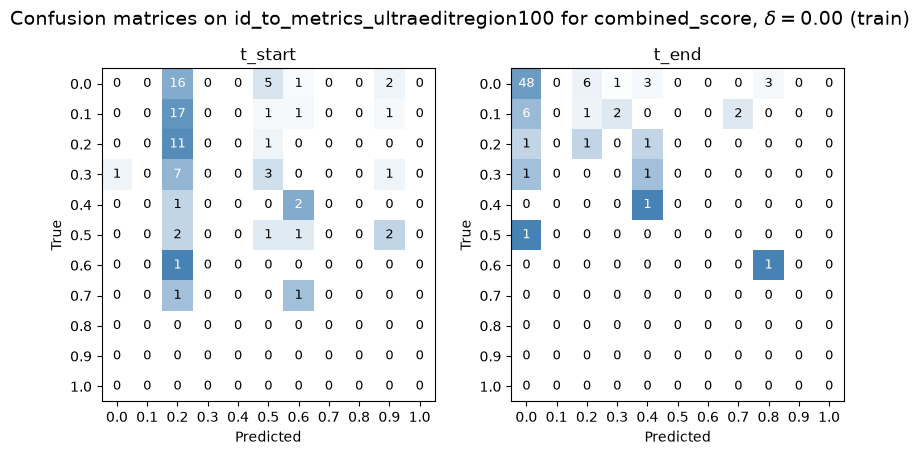

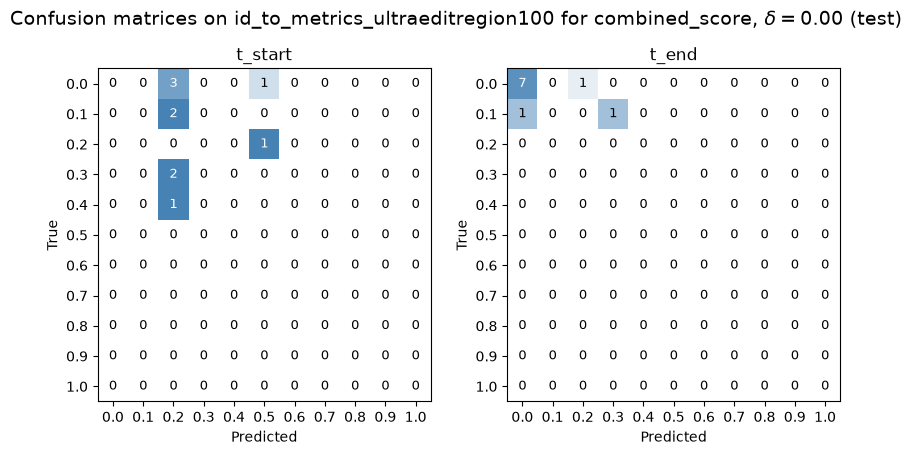

In [ ]:
"""
Plot row-normalised confusion matrices for both heads across all three splits. Each cell
shows the raw count as a number and is shaded by the fraction of true-class samples that
fell in that predicted bucket, making it easy to see whether errors cluster near the
diagonal (near-miss) or scatter widely (large mistakes).
"""
from sklearn.metrics import confusion_matrix
from matplotlib.colors import LinearSegmentedColormap

cmp_df = true_argmax_df[[SAMPLE_ID_COL, T_START_COL, T_END_COL]].merge(
    pred_argmax_df[[SAMPLE_ID_COL, T_START_COL, T_END_COL]],
    on=SAMPLE_ID_COL,
    suffixes=("_true", "_pred"),
)
for col in (T_START_COL, T_END_COL):
    cmp_df[f"{col}_true"] = cmp_df[f"{col}_true"].astype(float)
    cmp_df[f"{col}_pred"] = cmp_df[f"{col}_pred"].astype(float)

BUCKET_LABELS_START = [f"{v:.1f}" for v in GRID_T_START]
BUCKET_LABELS_END = [f"{v:.1f}" for v in GRID_T_END]
t_start_to_idx = {float(v): i for i, v in enumerate(GRID_T_START)}
t_end_to_idx = {float(v): i for i, v in enumerate(GRID_T_END)}

results = {}
for split_name, split_df in splits.items():
    split_cmp = cmp_df[cmp_df[SAMPLE_ID_COL].isin(split_df[SAMPLE_ID_COL].unique())]
    results[split_name] = {
        "true_start": split_cmp[f"{T_START_COL}_true"].map(t_start_to_idx).to_numpy(),
        "pred_start": split_cmp[f"{T_START_COL}_pred"].map(t_start_to_idx).to_numpy(),
        "true_end": split_cmp[f"{T_END_COL}_true"].map(t_end_to_idx).to_numpy(),
        "pred_end": split_cmp[f"{T_END_COL}_pred"].map(t_end_to_idx).to_numpy(),
    }

cmap = LinearSegmentedColormap.from_list("wb", ["white", "steelblue"])

def plot_confusion(ax, true, pred, title, bucket_labels):
    # Plot confusion matrix for t_start and t_end
    n_buckets = len(bucket_labels)
    cm = confusion_matrix(true, pred, labels=list(range(n_buckets)))
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True).clip(min=1)
    im = ax.imshow(cm_norm, cmap=cmap, vmin=0, vmax=1)
    for i in range(n_buckets):
        for j in range(n_buckets):
            ax.text(
                j, i, f"{cm[i, j]}",
                ha="center", va="center", fontsize=9,
                color="white" if cm_norm[i, j] > 0.5 else "black",
            )
    ax.set_xticks(range(n_buckets))
    ax.set_yticks(range(n_buckets))
    ax.set_xticklabels(bucket_labels)
    ax.set_yticklabels(bucket_labels)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(title)
    ax.set_aspect("equal", adjustable="box")
    return im

def plot_split(split):
    # Create separate confusion matrices for t_start and t_end
    r = results[split]
    fig, axes = plt.subplots(1, 2, figsize=(10, 4.5), sharey=True)
    plot_confusion(axes[0], r["true_start"], r["pred_start"], f"t_start", BUCKET_LABELS_START)
    plot_confusion(axes[1], r["true_end"], r["pred_end"], f"t_end", BUCKET_LABELS_END)
    for ax in axes:
        ax.tick_params(axis="y", labelleft=True)
        ax.set_ylabel("True")
    fig.suptitle(fig_title("Confusion matrices", split), fontsize=14)
    fig.subplots_adjust(wspace=0.12, top=0.85)
    plt.show()
    plt.close(fig)

for split in ["train", "test"]:
    plot_split(split)

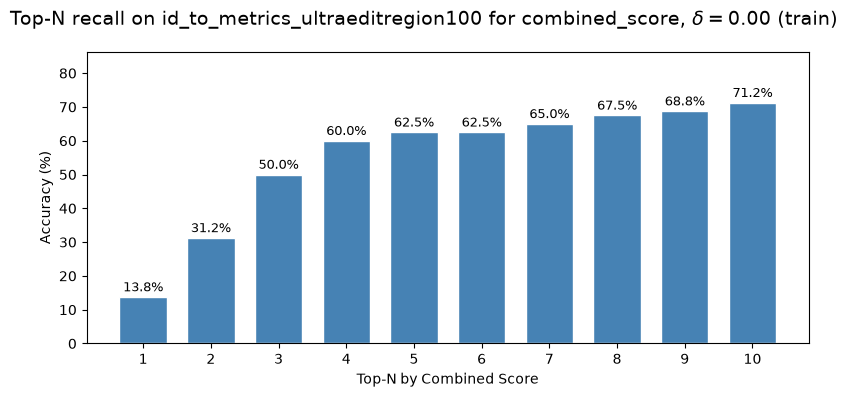

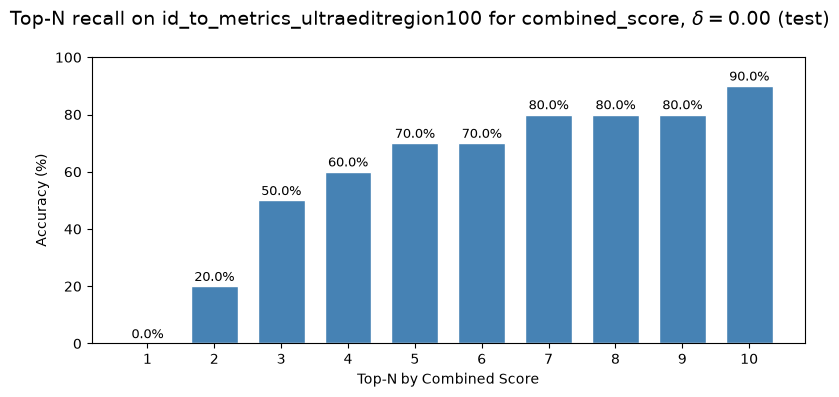

In [43]:
# Top-N accuracy: is the true-best cell in the model's top-N predictions by T_TARGET_COL?

def true_best_in_top_n_pct(true_df, pred_df, n_values):
    """Percent of samples whose oracle argmax is inside pred top-N (by T_TARGET_COL)."""
    true_best = true_df.loc[
        true_df.groupby(SAMPLE_ID_COL)[T_TARGET_COL].idxmax(),
        [SAMPLE_ID_COL, T_START_COL, T_END_COL],
    ]
    n_img = len(true_best)
    out = []
    for n in n_values:
        hits = 0
        for row in true_best.itertuples():
            pred_top = pred_df[pred_df[SAMPLE_ID_COL] == row.sample_id].nlargest(n, T_TARGET_COL)
            pred_cells = set(zip(pred_top[T_START_COL].astype(float), pred_top[T_END_COL].astype(float)))
            true_cell = (float(getattr(row, T_START_COL)), float(getattr(row, T_END_COL)))
            hits += true_cell in pred_cells
        out.append(100.0 * hits / n_img)
    return np.array(out)


def plot_top_n_recall(split_name, split_df):
    split_ids = split_df[SAMPLE_ID_COL].unique()
    split_true_df = true_df[true_df[SAMPLE_ID_COL].isin(split_ids)]
    split_pred_df = pred_df[pred_df[SAMPLE_ID_COL].isin(split_ids)]

    top_k = np.arange(1, 11)
    n_cells = split_pred_df.groupby(SAMPLE_ID_COL).size().iloc[0]
    top_k_acc = true_best_in_top_n_pct(split_true_df, split_pred_df, top_k)
    x_labels = [f"{n}" for n in top_k] # \n({100.0 * n / n_cells:.1f}%)

    fig, ax = plt.subplots(figsize=(8, 4))
    bars = ax.bar(top_k, top_k_acc, color="steelblue", edgecolor="white", width=0.7)
    ax.set_xlabel(f"Top-N by {T_TARGET_LABEL}")
    ax.set_ylabel("Accuracy (%)")
    ax.set_xticks(top_k)
    ax.set_xticklabels(x_labels)
    ax.set_ylim(0, min(100, top_k_acc.max() + 15))
    for bar, pct in zip(bars, top_k_acc):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.8,
            f"{pct:.1f}%",
            ha="center",
            va="bottom",
            fontsize=9,
        )
    fig.suptitle(fig_title("Top-N recall", split_name), fontsize=14)
    plt.tight_layout()
    plt.show()


for split_name, split_df in [("train", train_df), ("test", test_df)]:
    plot_top_n_recall(split_name, split_df)


In [68]:
# Metric summaries on test, plus deltas vs default.
from IPython.display import display

METRICS = [PSNR_COL, CLIP_COL, T_TARGET_COL]
STATS = ["mean", "median", "std", "min", "max"]
test_ids = set(test_df[SAMPLE_ID_COL].unique())

def metric_rows(df):
    out = df[df[SAMPLE_ID_COL].isin(test_ids)][[SAMPLE_ID_COL, *METRICS]].copy()
    out[METRICS] = out[METRICS].apply(pd.to_numeric)
    return out.set_index(SAMPLE_ID_COL)

default = true_df[
    np.isclose(true_df[T_START_COL].astype(float), DEFAULT_T_START)
    & np.isclose(true_df[T_END_COL].astype(float), DEFAULT_T_END)
]
default, true_best, pred_best = map(metric_rows, [default, true_argmax_df, pred_argmax_df])

# Create deltas columns.
selections = {"Default": default, "True Best": true_best, "Pred Best": pred_best}
values = {name: df.agg(STATS) for name, df in selections.items()}
deltas = {
    "Δ True Best": (true_best - default).agg(STATS),
    "Δ Pred Best": (pred_best - default).agg(STATS),
    "Δ Pred True": (pred_best - true_best).agg(STATS),
}
columns = ["Default", "True Best", "Δ True Best", "Pred Best", "Δ Pred Best", "Δ Pred True"]

print(fig_title("Comparative stats", "test"))
for metric in METRICS:
    # Create a table with the specified columns.
    table = pd.DataFrame({
        "Default": values["Default"][metric],
        "True Best": values["True Best"][metric],
        "Δ True Best": deltas["Δ True Best"][metric],
        "Pred Best": values["Pred Best"][metric],
        "Δ Pred Best": deltas["Δ Pred Best"][metric],
        "Δ Pred True": deltas["Δ Pred True"][metric],
    })[columns]
    # Format the table with the specified column formatting.
    print("\n", metric)
    display(table.style.format({
        col: ("{:+.3f}" if col.startswith("Δ") else "{:.3f}") for col in columns
    }))

Comparative stats on id_to_metrics_ultraeditregion100 for combined_score, $\delta={0.00}$ (test)

 psnr


,Default,True Best,Δ True Best,Pred Best,Δ Pred Best,Δ Pred True
mean,15.809,29.938,+14.129,24.386,+8.577,-5.551
median,15.308,29.398,+13.253,24.862,+9.382,-6.053
std,2.030,4.075,+3.483,2.550,+2.606,+2.996
min,13.570,24.391,+8.789,18.347,+2.744,-11.685
max,19.543,37.060,+21.895,27.592,+11.530,-1.124



 clip_similarity_target_image_edit_part


,Default,True Best,Δ True Best,Pred Best,Δ Pred Best,Δ Pred True
mean,21.749,20.544,-1.205,17.706,-4.043,-2.838
median,21.831,19.841,-0.117,17.443,-2.873,-1.313
std,5.217,5.396,+4.471,2.000,+4.735,+4.834
min,13.861,14.904,-9.251,15.142,-13.238,-14.432
max,32.711,33.905,+4.280,21.428,+2.357,+2.926



 combined_score


,Default,True Best,Δ True Best,Pred Best,Δ Pred Best,Δ Pred True
mean,0.390,0.601,+0.211,0.564,+0.174,-0.037
median,0.389,0.559,+0.208,0.571,+0.188,-0.042
std,0.094,0.112,+0.054,0.073,+0.072,+0.070
min,0.253,0.495,+0.124,0.479,+0.066,-0.186
max,0.598,0.877,+0.291,0.692,+0.257,+0.054


In [44]:

"""
Per-image Spearman rho — does M rank grid cells correctly within each image?

For each image, correlate the ranked order of true vs predicted values across
all 121 cells. Reported for PSNR, CLIP, and scalarized m separately.

Interpretation:
  - median rho > 0.5   -> strong within-image ranking; T argmax is well-founded.
  - median rho 0.2-0.5 -> weak but nonzero signal; expect moderate regret.
  - median rho < 0.2   -> near-random ranking; T selection is unreliable.
  - frac rho < 0       -> fraction of images where M ranks backwards; should be ~0.
  - rho(m) matters most since T argmax operates on m, not raw PSNR/CLIP alone.
  - High rho(PSNR) but low rho(CLIP) -> check scalarization weights in settings.py.
"""

def per_image_spearman(true_grid, pred_grid):
    rhos = []
    for k in range(true_grid.shape[0]):
        rho, _ = spearmanr(true_grid[k].ravel(), pred_grid[k].ravel())
        rhos.append(np.nan if rho is None else float(rho))
    return np.array(rhos)

rho_psnr = per_image_spearman(true_psnr, pred_psnr)
rho_clip = per_image_spearman(true_clip, pred_clip)
rho_m = per_image_spearman(true_m, pred_m)
for name, r in [("PSNR", rho_psnr), ("CLIP", rho_clip), ("m", rho_m)]:
    rv = r[np.isfinite(r)]
    print(f"{name:5s}  median rho={np.nanmedian(r):.3f}  frac<0.2={np.mean(rv < 0.2):.2f}  frac<0={np.mean(rv < 0):.2f}")

fig, axes = plt.subplots(1, 3, figsize=(12, 3))
for ax, (name, r) in zip(axes, [("PSNR", rho_psnr), ("CLIP", rho_clip), ("m", rho_m)]):
    rv = r[np.isfinite(r)]
    if len(rv): ax.hist(rv, bins=min(30, max(3, len(rv))), edgecolor="white")
    ax.axvline(0, color="k", lw=0.5); ax.set_title(f"rho: {name}"); ax.set_xlabel("Spearman rho")
fig.suptitle(fig_title("Per-image Spearman", PLOT_SPLIT), fontsize=14); plt.tight_layout(); plt.show()


NameError: name 'true_psnr' is not defined

In [ ]:

"""
Selection regret — how much true m do we lose by following argmax(pred_m)?

regret = true_m[oracle cell] - true_m[cell chosen by T]
Lower is better. Zero means T picked the true-best cell.

Interpretation:
  - median regret ~ 0, frac~0 high  -> T matches oracle on most images.
  - median regret < noise floor    -> gains are within label noise; defaults may suffice.
  - median regret >> noise floor   -> T is leaving real quality on the table.
  - p90 regret much larger than median -> a few images have catastrophic mis-selection.
  - Compare regret median to noise_floor_m (cell 5) to judge practical significance.
"""

def regret(true_m_grid, pred_m_grid):
    out = np.zeros(true_m_grid.shape[0])
    for k in range(true_m_grid.shape[0]):
        chosen = np.unravel_index(pred_m_grid[k].argmax(), pred_m_grid[k].shape)
        out[k] = true_m_grid[k].max() - true_m_grid[k][chosen]
    return out

reg = regret(true_m, pred_m)
print(f"regret  median={np.median(reg):.4f}  p90={np.percentile(reg, 90):.4f}  frac~0={np.mean(reg < 1e-3):.2f}")
fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(reg, bins=min(30, max(5, N_IMG // 2)), edgecolor="white")
ax.set_xlabel("regret (m units)"); ax.set_ylabel("count"); ax.set_title("selection regret")
fig.suptitle(fig_title("Selection regret", PLOT_SPLIT), fontsize=14); plt.tight_layout(); plt.show()


In [ ]:

"""
Top-1 hit rate and top-3 overlap — does argmax(pred) land on the true best cell?

top-1 hit rate: fraction of images where pred argmax == true argmax (exact match).
top-3 overlap:  fraction of the true top-3 cells that also appear in pred top-3.

Interpretation:
  - hit rate > 0.3 on a 121-cell grid  -> better than chance (~0.008); promising.
  - hit rate > 0.5                     -> strong exact-match performance.
  - high top-3 overlap, low hit rate   -> M finds the right region but not exact peak.
  - both near 0                        -> ranking failure; check Spearman and surface plots.
  - top-3 overlap is more forgiving; useful when near-optimal cells are interchangeable.
"""

def topk_metrics(true_m_grid, pred_m_grid, k=3):
    hit1, ov = [], []
    for i in range(true_m_grid.shape[0]):
        t_order = true_m_grid[i].ravel().argsort()[::-1]
        p_order = pred_m_grid[i].ravel().argsort()[::-1]
        hit1.append(t_order[0] == p_order[0])
        ov.append(len(set(t_order[:k]) & set(p_order[:k])) / k)
    return np.mean(hit1), np.mean(ov)

h1, ov3 = topk_metrics(true_m, pred_m, k=3)
print(f"top-1 hit rate={h1:.3f}   top-3 overlap={ov3:.3f}")


### Top-N recall — is the true-best cell among T's top-N predicted outputs?

For each N, plot the percent of images whose oracle-best `(t_start, t_end)` cell appears in T's top-N cells ranked by predicted `m`.

**Interpretation**
- Steep rise in the first few N → T ranks the true best near the top quickly.
- Flat near 0 for small N → ranking failure; true best is rarely highly ranked.
- At N=1, equals top-1 hit rate; at N=121, must reach 100%.

In [ ]:
def true_best_in_top_n_pct(true_m_grid, pred_m_grid, n_values):
    """Percent of images with oracle argmax inside pred top-N (by m)."""
    n_img = true_m_grid.shape[0]
    out = []
    for n in n_values:
        hits = 0
        for i in range(n_img):
            t_order = true_m_grid[i].ravel().argsort()[::-1]
            p_order = pred_m_grid[i].ravel().argsort()[::-1]
            if t_order[0] in p_order[:n]:
                hits += 1
        out.append(100.0 * hits / n_img)
    return np.array(out)

In [ ]:
n_values = np.arange(1, CELLS + 1)
top_n_pct = true_best_in_top_n_pct(true_m, pred_m, n_values)

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(n_values, top_n_pct, marker="o", markersize=3, linewidth=1.5)
ax.set_xlabel("True Best in Top-N Predictions")
ax.set_ylabel("Percent of Images")
ax.set_xlim(1, CELLS)
ax.set_ylim(0, 100)
ax.grid(True, alpha=0.3)
for n_mark in (1, 3, 5, 10, 25, CELLS):
    pct = top_n_pct[n_mark - 1]
    ax.axvline(n_mark, color="k", linestyle=":", alpha=0.2)
    ax.annotate(f"N={n_mark}: {pct:.0f}%", xy=(n_mark, pct), xytext=(4, 4),
                textcoords="offset points", fontsize=8)
fig.suptitle(fig_title("Oracle in Top-N Predictions", PLOT_SPLIT), fontsize=14)
plt.tight_layout(); plt.show()

In [ ]:
print(f"top-1={top_n_pct[0]:.1f}%  top-3={top_n_pct[2]:.1f}%  top-10={top_n_pct[9]:.1f}%  top-25={top_n_pct[24]:.1f}%")

In [ ]:

"""
Argmax collapse — does T pick diverse cells or always the same (t_start, t_end)?

Compare the spatial spread of true vs predicted argmax cells across images.
Red X marks the paper-default cell (t_start=0.9, t_end=0.3).

Interpretation:
  - pred spread ~ true spread, many unique pred cells -> T adapts per image (good).
  - pred spread << true spread                       -> collapse; M surface is too flat.
  - unique pred cells = 1-2 out of 121               -> T ignores image content entirely.
  - pred mass on default cell while true is spread   -> gate may be too conservative.
  - pred mass at grid edges while true is interior   -> M may overfit boundary artifacts.
"""

def argmax_cells(grid):
    return np.array([np.unravel_index(grid[k].argmax(), grid[k].shape) for k in range(grid.shape[0])])

true_arg = argmax_cells(true_m)
pred_arg = argmax_cells(pred_m)

def spread(arg):
    return arg[:, 0].std() + arg[:, 1].std()

print(f"true argmax spread = {spread(true_arg):.3f}")
print(f"pred argmax spread = {spread(pred_arg):.3f}")
print(f"unique pred cells = {len(set(map(tuple, pred_arg)))} / {CELLS}")

fig, axes = plt.subplots(1, 2, figsize=(8, 4), sharex=True, sharey=True)
for ax, arg, title in zip(axes, [true_arg, pred_arg], ["true argmax", "pred argmax"]):
    H = np.zeros((N1, N2))
    for i, j in arg: H[i, j] += 1
    ax.imshow(H.T, origin="lower", cmap="Blues"); ax.set_title(title)
    ax.scatter([T_START_DELTA], [T_END_DELTA], c="r", marker="x", label="default")
    ax.set_xlabel("t_start idx"); ax.set_ylabel("t_end idx"); ax.legend(fontsize=8)
fig.suptitle(fig_title("Argmax collapse", PLOT_SPLIT), fontsize=14); plt.tight_layout(); plt.show()


In [ ]:

"""
Label noise floor (optional) — minimum meaningful gain from re-rendering.

Requires a second CSV of the same grid cells rendered with a different seed.
noise_floor_m = median |true_m - second_seed_m| across cells.

Interpretation:
  - noise floor ~ 0.01-0.05 (typical) -> small m differences below this are not trustworthy.
  - regret median < noise floor         -> T errors are within measurement noise; acceptable.
  - regret median >> noise floor        -> real quality loss; M or T needs improvement.
  - SKIP if no second-seed data; gate and regret still usable with NOISE_FLOOR_M=0.
"""

SECOND_SEED_CSV = None
if SECOND_SEED_CSV is None or not Path(SECOND_SEED_CSV).exists():
    print("SKIP: set SECOND_SEED_CSV to compute label noise floor.")
    noise_floor_m = np.nan
else:
    second = pd.read_csv(SECOND_SEED_CSV)
    if TARGET_T_DELTA is not None: second = second[second[T_DELTA_COL] == TARGET_T_DELTA]
    second = second[second[SAMPLE_ID_COL].isin(SAMPLE_IDS)]
    s_psnr, _ = df_to_metric_grids(second, SAMPLE_IDS, T_START_VALUES, T_END_VALUES, PSNR_COL)
    s_clip, _ = df_to_metric_grids(second, SAMPLE_IDS, T_START_VALUES, T_END_VALUES, CLIP_COL)
    noise_floor_m = np.nanmedian(np.abs(true_m - scalarize(s_psnr, s_clip, COMBINED_BOUNDS)))
    print(f"noise floor ~ {noise_floor_m:.4f}  vs regret median {np.median(reg):.4f}")


In [ ]:

"""
Human-preferred cell rank (optional) — does the true-best m cell match human judgment?

Populate eyeball_cells = {image_index: (t_start_idx, t_end_idx)} with manually
chosen preferred cells. Reports where those cells rank under true_m.

Interpretation:
  - median rank near 0 (top of 121)  -> m metric aligns with human preference.
  - median rank >> 10                -> m may optimize the wrong objective; revisit T_TARGET_FUNC.
  - frac top-5 high                  -> even if not exact best, m finds competitive cells.
  - SKIP unless you have human annotations; automated metrics may suffice.
"""

eyeball_cells: dict[int, tuple[int, int]] = {}
if not eyeball_cells:
    print("SKIP: populate eyeball_cells with {image_index: (i, j)}.")
else:
    ranks = []
    for k, (i, j) in eyeball_cells.items():
        order = true_m[k].ravel().argsort()[::-1]
        rank = int(np.where(order == np.ravel_multi_index((i, j), (N1, N2)))[0][0])
        ranks.append(rank)
    print(f"median rank={np.median(ranks):.0f}/{CELLS}  frac top-5={np.mean(np.array(ranks) < 5):.2f}")


In [ ]:

"""
Fresh-seed realized gain (optional) — does T's pick actually improve a new render?

Re-render each image at T's chosen cell vs the default cell with a fresh seed,
then measure realized Δm. Requires wiring render_and_score() to ChordEditPipeline.

Interpretation:
  - realized Δm median > noise floor  -> T selections produce real edits, not just metric gains.
  - frac > noise_floor high           -> most flagged images genuinely improve on re-render.
  - realized Δm ~ 0                   -> M predictions don't transfer to actual renders.
  - SKIP unless you can render; surrogate-only eval (regret, Spearman) is the default path.
"""

FRESH_SEED = None

def render_and_score(image_k, t_start, t_end, seed):
    raise NotImplementedError("Wire to ChordEditPipeline")

if FRESH_SEED is None:
    print("SKIP: set FRESH_SEED and implement render_and_score().")
else:
    realized = []
    for k in range(N_IMG):
        i, j = np.unravel_index(pred_m[k].argmax(), pred_m[k].shape)
        psnr_c, clip_c = render_and_score(k, T_START_VALUES[i], T_END_VALUES[j], FRESH_SEED)
        psnr_d, clip_d = render_and_score(k, T_START_VALUES[T_START_DELTA], T_END_VALUES[T_END_DELTA], FRESH_SEED)
        realized.append(scalarize(np.array([psnr_c]), np.array([clip_c]), COMBINED_BOUNDS)[0]
                        - scalarize(np.array([psnr_d]), np.array([clip_d]), COMBINED_BOUNDS)[0])
    realized = np.array(realized)
    nf = noise_floor_m if not np.isnan(noise_floor_m) else 0.0
    print(f"realized Δm median={np.median(realized):.4f}  frac>noise_floor={np.mean(realized > nf):.2f}")


In [ ]:

"""
Deviate-or-default gate — should T change from paper defaults on this image?

T deviates only when pred_gain = max(pred_m) - pred_m[default] > noise_floor.
Compare flagged images to those truly improvable under true_m.

Interpretation:
  - precision high -> when T deviates, a better cell really exists (few false alarms).
  - recall high    -> T catches most images that truly benefit from non-default timesteps.
  - precision low  -> T deviates too often; reduce noise floor or improve M calibration.
  - recall low     -> T stays on defaults too often; lower noise floor or improve M ranking.
  - n_flagged = 0  -> gate never deviates; either defaults are optimal or M sees no gain.
  - all flagged    -> gate always deviates; noise floor may be too low or M overconfident.
"""

nf = noise_floor_m if "noise_floor_m" in dir() and not np.isnan(noise_floor_m) else NOISE_FLOOR_M
default_m = true_m[:, T_START_DELTA, T_END_DELTA]
truly_improvable = (true_m.max(axis=(1, 2)) - default_m) > nf
pred_gain = pred_m.max(axis=(1, 2)) - pred_m[:, T_START_DELTA, T_END_DELTA]
flagged = pred_gain > nf
tp = int(np.sum(flagged & truly_improvable))
precision = tp / max(int(flagged.sum()), 1)
recall = tp / max(int(truly_improvable.sum()), 1)
print(f"gate  precision={precision:.3f}  recall={recall:.3f}  ({flagged.sum()} flagged of {N_IMG})  noise_floor={nf:.4f}")


In [ ]:

"""
Error stratification — where does T fail?

Relates regret to default-cell quality and whether the true optimum sits on the
grid boundary (t_start or t_end at 0.0 or 1.0).

Interpretation:
  - regret vs default_quality correlation near 0 -> errors are not driven by baseline quality.
  - higher regret when best_at_edge=True       -> M struggles at grid boundaries; expected if
      training data is sparse near edges.
  - higher regret when best_at_edge=False      -> interior ranking failure; more concerning.
  - scatter cluster at high regret, low default -> images where defaults are poor and T also fails.
"""

df_err = pd.DataFrame({
    "sample_id": SAMPLE_IDS,
    "regret": reg,
    "default_quality": true_m[:, T_START_DELTA, T_END_DELTA],
    "best_at_edge": [(i in (0, N1-1)) or (j in (0, N2-1)) for i, j in true_arg],
})
print("regret vs default quality corr:", np.corrcoef(df_err["default_quality"], df_err["regret"])[0, 1])
print("regret by edge:", df_err.groupby("best_at_edge")["regret"].median().to_dict())
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].scatter(df_err["default_quality"], df_err["regret"], alpha=0.7)
axes[0].set_xlabel("default m"); axes[0].set_ylabel("regret")
axes[1].boxplot([df_err.loc[~df_err.best_at_edge, "regret"], df_err.loc[df_err.best_at_edge, "regret"]], tick_labels=["interior", "edge"])
axes[1].set_ylabel("regret")
fig.suptitle(fig_title("Error stratification", PLOT_SPLIT), fontsize=14); plt.tight_layout(); plt.show()


In [ ]:

"""
Sparse labeling budget sweep — regret vs number of labeled cells k.

Simulates labeling only k of 121 grid cells per image, then selecting from
that subset using pred_m. Compares structured policies vs dense argmax baseline.

Policies:
  - default:    label only the paper-default cell (k=1).
  - 1d_sweeps:  ~21 cells along t_start and t_end axes through the default.
  - 5x5:        25 cells on a coarse subgrid.
  - random:     k random cells per image.

Interpretation:
  - curve near dense-argmax dashed line at low k -> M generalizes; cheap labeling suffices.
  - curve flat and high even at k=121            -> dense labels don't help; M ranking is broken.
  - 1d_sweeps beats random at same k             -> structured sweeps are worth the render cost.
  - all policies converge at k=121                 -> sanity check; should match full-grid regret.
"""

from active_label import cells_to_mask, policy_1d_sweeps, policy_structured_5x5, policy_default_only

def regret_on_mask(true_m_grid, pred_m_grid, mask):
    out = np.zeros(true_m_grid.shape[0])
    for k in range(true_m_grid.shape[0]):
        masked = np.where(mask[k], pred_m_grid[k], -np.inf)
        chosen = np.unravel_index(masked.argmax(), masked.shape)
        out[k] = true_m_grid[k].max() - true_m_grid[k][chosen]
    return out

def policy_mask(policy_name, k, rng):
    mask_3d = np.zeros((N_IMG, N1, N2), dtype=bool)
    if policy_name == "random":
        for ki in range(N_IMG):
            for idx in rng.choice(CELLS, size=min(k, CELLS), replace=False):
                i, j = np.unravel_index(idx, (N1, N2))
                mask_3d[ki, i, j] = True
        return mask_3d
    cells = policy_default_only() if policy_name == "default" else (
        policy_structured_5x5() if policy_name == "5x5" else policy_1d_sweeps())
    base = cells_to_mask(cells, T_START_VALUES, T_END_VALUES)
    return np.broadcast_to(base, (N_IMG, N1, N2)).copy()

budgets = [1, 9, 21, 25, 49, 121]
policies = ["default", "1d_sweeps", "5x5", "random"]
rng_budget = np.random.default_rng(SEED)
fig, ax = plt.subplots(figsize=(8, 5))
for policy_name in policies:
    xs, ys = [], []
    for k in budgets:
        if policy_name != "random" and k not in (1, 21, 25, 121): continue
        xs.append(k); ys.append(np.median(regret_on_mask(true_m, pred_m, policy_mask(policy_name, k, rng_budget))))
    ax.plot(xs, ys, marker="o", label=policy_name)
ax.axhline(np.median(reg), color="k", linestyle="--", alpha=0.5, label="dense argmax")
ax.set_xlabel("label budget k"); ax.set_ylabel("median regret"); ax.legend()
fig.suptitle(fig_title("Regret vs label budget", PLOT_SPLIT), fontsize=14); plt.tight_layout(); plt.show()


In [ ]:

"""
T evaluation summary — key decision metrics in one place.

Use this cell to decide whether to deploy T with the current M checkpoint:
  - Spearman m median > 0.4 AND regret median < noise floor  -> deploy with gate.
  - Argmax collapse (spread(pred) << spread(true))             -> do not deploy; fix M first.
  - Gate recall < 0.5 with many improvable images              -> lower noise floor or retrain M.
  - Sparse-label curves close to dense at k <= 25              -> active labeling is viable.
"""

print(fig_title("T summary", PLOT_SPLIT))
print(f"  split: {PLOT_SPLIT}  images: {N_IMG}  grid: {N1}x{N2}")
print(f"  Spearman m median: {np.nanmedian(rho_m):.3f}")
print(f"  regret median:     {np.median(reg):.4f}")
print(f"  top-1 / top-3:     {h1:.3f} / {ov3:.3f}")
print(f"  spread true/pred:  {spread(true_arg):.3f} / {spread(pred_arg):.3f}")
print(f"  gate prec/recall:  {precision:.3f} / {recall:.3f}")
